# automatically quantify images
a notebook to automatically quantify things in images

for now we will start with simple tif images and we won't need many or very advanced packages

In [2]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install matplotlib


[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Here we will place all of our imports

In [5]:
from matplotlib import pyplot as plt # for plotting
from skimage.io import imread, imsave # for reading/writing images
import numpy as np # for numerical operations
import os # for file handling
import tifffile # for reading TIFF metadata
from skimage.measure import label, regionprops # for quantifying objects in binary images
import pandas as pd # for data handling

The following code we will use to have access to files from our repository...

In [6]:

# Clone the repo if not already in Colab
if 'google.colab' in str(get_ipython()):
    if not os.path.exists('/content/NBCimageAnalysis'):
        !git clone https://github.com/FilLieb/NBCimageAnalysis.git
    os.chdir('/content/NBCimageAnalysis/learning/')
    print(os.listdir('.'))

next let's load an image with its associated binary images...

In [7]:
binary = imread('../data/artificial/test_3col.tif')
image = imread('../data/artificial/test_3col_intensities.tif')

print(binary.shape)
print(image.shape)


(1500, 1500, 3)
(1500, 1500, 3)


we can also check whether there is metadata associated and whether we can find the actual size of a pixel

In [8]:
with tifffile.TiffFile('../data/artificial/test_3col.tif') as tif:
    page = tif.pages[0]

    # Check for XResolution / YResolution tags
    x_res = page.tags.get('XResolution')
    y_res = page.tags.get('YResolution')

    if x_res:
        # Tags store resolution as a fraction (pixels per unit)
        num, denom = x_res.value
        x_voxel = denom / num  # unit size per pixel
        print(f"X voxel size: {x_voxel}")
    
    if y_res:
        # Tags store resolution as a fraction (pixels per unit)
        num, denom = y_res.value
        y_voxel = denom / num  # unit size per pixel
        print(f"Y voxel size: {y_voxel}")

X voxel size: 0.017618970246598278
Y voxel size: 0.017618970246598278


and let's see what we have

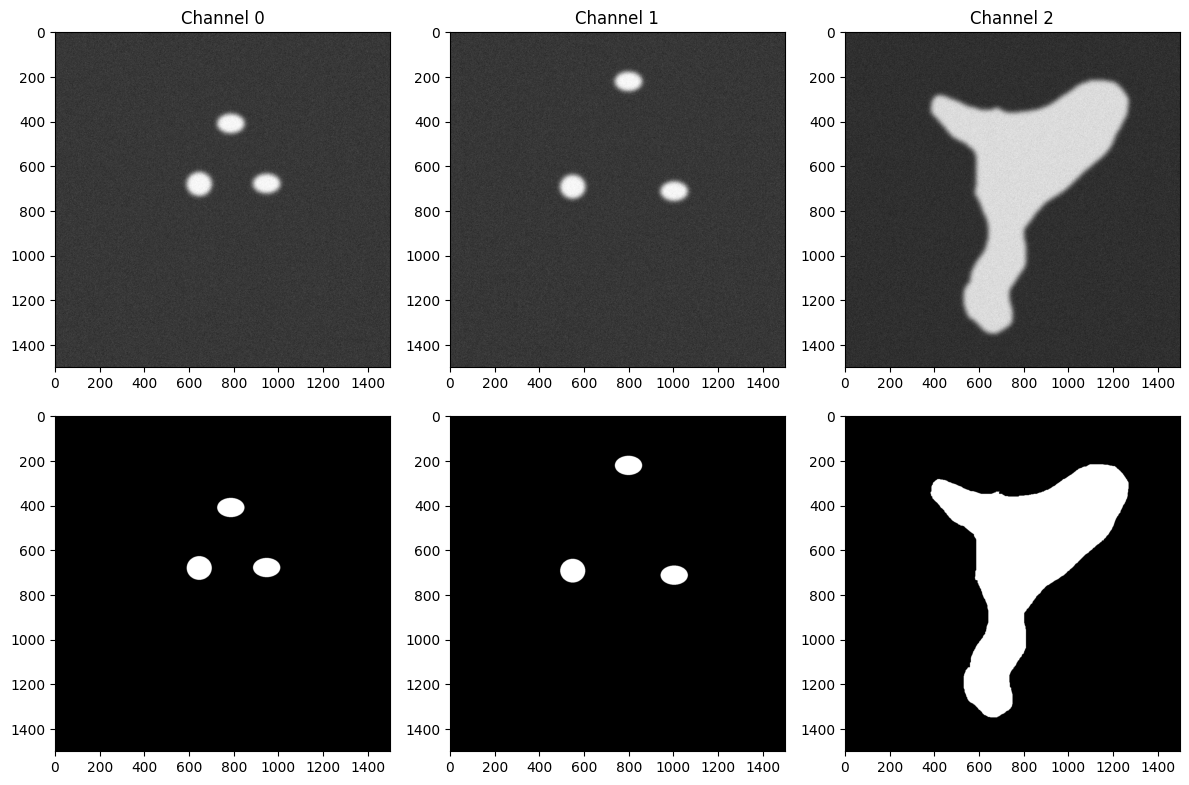

In [9]:
# make a quick figure to display individual channels
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(image[:,:,0], cmap='gray')
axes[0, 0].set_title("Channel 0")

axes[0, 1].imshow(image[:,:,1], cmap='gray')
axes[0, 1].set_title("Channel 1")

axes[0, 2].imshow(image[:,:,2], cmap='gray')
axes[0, 2].set_title("Channel 2")

axes[1, 0].imshow(binary[:,:,0], cmap='gray')
axes[1, 1].imshow(binary[:,:,1], cmap='gray')
axes[1, 2].imshow(binary[:,:,2], cmap='gray')


plt.tight_layout()
plt.show()

In order to quantify "things" from our images we will use scikit-image. The first thing we need to do is label our image, for example all pixels of the same value belong to one object. This way we can treat them as different entities or clusters.

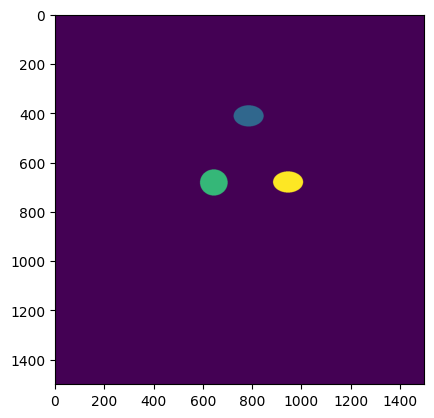

In [10]:
labeled = label(binary[:,:,0])
plt.imshow(labeled)

using this labeled image, we can get the "properties" of the individual entities

In [11]:
regions = regionprops(labeled) #access properties of each labeled region

print(f"The area of the first region is: {regions[0].area}") # print area of first region
print(f"The number of pixels in the first region is: {regions[0].num_pixels}") # print number of pixels in first region
print(f"The maximum feret diameter of the first region is: {regions[0].feret_diameter_max}") # print max feret diameter of first region




The area of the first region is: 8232.0
The number of pixels in the first region is: 8232
The maximum feret diameter of the first region is: 122.6906679417795


If we wanted to convert the area into scaled units, we need to use the info from the metadata of the image.

We have already done the important part of the work and can use the variables x_voxel and y_voxel.

In [12]:
print(f"The area of the first region is: {regions[0].area*x_voxel*y_voxel} µm²") # print area of first region

The area of the first region is: 2.5554442225158427 µm²


We can use the information in regions to calculate the average area or average maximum feret diameter.

In [13]:
print(f"The average area of all regions is: {np.mean([r.area for r in regions])*x_voxel*y_voxel} µm²") # print average area of all regions
print(f"The average maximum feret diameter of all regions is: {np.mean([r.feret_diameter_max for r in regions])*x_voxel} µm") # print average feret diameter of all regions


The average area of all regions is: 2.669267863784365 µm²
The average maximum feret diameter of all regions is: 2.1064311001480345 µm


If we simply want to know the number of clusters, we can check the length (i.e. number of objects)...

In [14]:
print(f"There are {len(regions)} clusters in this image.") # print total number of regions

There are 3 clusters in this image.


We can also use our labeled image and measure the intensities in the corresponding original image...

In [15]:
props = regionprops(labeled, intensity_image=image[:,:,0])#access properties of each labeled region, using intensity image for intensity-based measurements
print(f" The mean intensity of the first region is: {props[0].mean_intensity}") # print mean intensity of first region
print(f" The maximum intensity of the first region is: {props[0].max_intensity}") # print max intensity of first region
print(f" The minimum intensity of the first region is: {props[0].min_intensity}") # print min intensity of first region

 The mean intensity of the first region is: 219.99599125364432
 The maximum intensity of the first region is: 255.0
 The minimum intensity of the first region is: 92.0


We could also ask the question of how many of our three clusters are actually synaptic cluster, i.e. "touching" a presynaptic partner. 

In [ ]:
gphn = binary[:,:,0]
gphn_labeled = label(gphn)

vgat = binary[:,:,1]
vgat_labeled = label(vgat)

# Find where gphn and vgat overlap
overlap = gphn & vgat  # element-wise AND on binary images

# Find which gphn labels are present in the overlap region
overlapping_labels = np.unique(gphn_labeled[overlap])
overlapping_labels = overlapping_labels[overlapping_labels != 0]  # remove background

print(f"Found {len(overlapping_labels)} gphn clusters overlapping with vgat")

Same as before, we can label this image and count the length....

In [109]:
labeled_synaptic = label(overlap)
regions_synaptic = regionprops(labeled_synaptic)
print(f"There are {len(regions_synaptic)} out of {len(regions)} synaptic clusters. Which is {len(regions_synaptic)/len(regions)*100:.2f}% of all clusters.")

There are 2 out of 3 synaptic clusters. Which is 66.67% of all clusters.


In [ ]:
def execute(file, root):
    print(f"Found image: {file}")
    folder_name = os.path.splitext(os.path.basename(file))[0] # removes the .lif extension
    folder_path = os.path.join(root, folder_name)
    os.makedirs(folder_path, exist_ok=True)

    lif = LifFile(file)

    for img in lif.get_iter_image():
        print(img.name, img.dims)
        channels_array = np.stack([np.array(channel) for channel in img.get_iter_c(t=0, z=0)])
        make_masks("DAAO", channels_array[0], folder_path, img.name)
        make_masks("vGAT", channels_array[1], folder_path, img.name)
        make_masks("Cre", channels_array[2], folder_path, img.name)
        make_masks("Gphn", channels_array[3], folder_path, img.name)


In [ ]:
# make mask per channel
def make_masks(channel, array, path, image):
    print("Generating masks...")

    out_file = os.path.join(path, image + '_' + channel + '_labels.tif')
    
    cl_filename = '../training_4_channels/' + channel + '/models/' + channel + '_object_model.cl'
    segmenter = apoc.ObjectSegmenter(opencl_filename=cl_filename)
    labels = segmenter.predict(array)

    imsave(out_file, labels)

In [ ]:
for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith("High Density.lif"):
            full_path = os.path.join(root, file)
            print(full_path)
            execute(full_path, root)

print("...completed.")


In [ ]:
for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith("_labels.tif"):
            label_path = os.path.join(root, file)
            label = imread(label_path)
            folder_name = os.path.basename(root)
            plt.figure()
            plt.imshow(label)
            plt.title("predicted labels - " + folder_name + ": " + file)
            plt.show()
